In [99]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers



In [102]:
rawX = np.load('../new2_traininginput_3d.npy')
rawY = np.load('../new2_traininglabel_3d.npy')

In [103]:
rawX.shape, rawY.shape

((39875, 30, 4), (39875,))

In [104]:
rawY

array([0., 0., 0., ..., 1., 1., 1.])

In [105]:
rawX = np.expand_dims(rawX, axis=2)

In [106]:
rawX.shape, rawY.shape

((39875, 30, 1, 4), (39875,))

In [109]:
np.random.seed(42)

input_shape = (30, 1,  4)  # (height width, channels)
X = rawX
y = rawY


In [110]:
# #manual split
# X_train, X_val, y_train, y_val = X[:15000], X[15000:], y[:15000], y[15000:]

In [111]:
# from sklearn.model_selection import train_test_split

# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=22)

In [112]:
# X_train.shape, X_val.shape, y_train.shape, y_val.shape

In [113]:
model = models.Sequential()
model.add(layers.Input(shape=input_shape))
# model.add(layers.LSTM(units=50, return_sequences=True))
# model.add(layers.Dropout(0.2))
# model.add(layers.LSTM(units=50, return_sequences=False))
# model.add(layers.Dropout(0.2))
# model.add(layers.Dense(units=1))
model.add(layers.Conv2D(filters=8, kernel_size=(3, 1), activation='relu'))
model.add(layers.Conv2D(filters=16, kernel_size=(3, 1), activation='relu'))
model.add(layers.MaxPooling2D(pool_size=(2, 1))) 
model.add(layers.Conv2D(filters=8, kernel_size=(3, 1), activation='relu'))
# model.add(layers.Conv2D(filters=8, kernel_size=(5, 1), activation='relu'))
# # model.add(layers.Conv2D(filters=8, kernel_size=(4, 1), activation='relu'))
# # model.add(layers.Conv2D(filters=32, kernel_size=(3, 1), activation='relu'))
model.add(layers.MaxPooling2D(pool_size=(2, 1)))
# model.add(layers.Conv2D(filters=16, kernel_size=(4, 1), activation='relu'))
# model.add(layers.Conv2D(filters=16, kernel_size=(3, 1), activation='relu'))
# model.add(layers.Conv2D(filters=8, kernel_size=(8, 1), activation='relu'))
# model.add(layers.Conv2D(filters=4, kernel_size=(8, 1), activation='relu'))
# model.add(layers.Conv2D(filters=8, kernel_size=(5, 1), activation='relu'))
# model.add(layers.MaxPooling2D(pool_size=(2, 1)))
# model.add(layers.Conv2D(filters=8, kernel_size=(8, 1), activation='relu'))
# model.add(layers.Conv2D(filters=4, kernel_size=(8, 1), activation='relu'))
# model.add(layers.Conv2D(filters=8, kernel_size=(5, 1), activation='relu'))
# model.add(layers.MaxPooling2D(pool_size=(2, 1)))
# model.add(layers.Conv2D(filters=8, kernel_size=(4, 1), activation='relu'))
# model.add(layers.MaxPooling2D(pool_size=(2, 1)))
# model.add(layers.Conv2D(filters=8, kernel_size=(5, 1), activation='relu'))
# model.add(layers.Conv2D(filters=4, kernel_size=(5, 1), activation='relu'))
# model.add(layers.MaxPooling2D(pool_size=(2, 1)))

model.add(layers.Flatten())

# model.add(layers.Dense(32, activation='relu'))
# model.add(layers.Dense(64, activation='relu'))
# model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dense(16, activation='relu'))
# model.add(layers.Dense(16, activation='relu'))
# model.add(layers.Dense(16, activation='relu'))
# model.add(layers.Dense(64, activation='relu'))
# model.add(layers.Dense(64, activation='relu'))
# model.add(layers.Dense(8, activation='relu'))
# model.add(layers.Dense(8, activation='relu'))
model.add(layers.Dropout(0.125))  # Dropout layer to prevent overfitting
# model.add(layers.Dense(8, activation='relu',kernel_regularizer=regularizers.l1(0.0001)))
# model.add(layers.Dense(3, activation='softmax'))  # 3 classes classification
model.add(layers.Dense(1, activation='sigmoid'))  # binary classification

In [114]:
model.compile(
        optimizer='adam',
        # loss='sparse_categorical_crossentropy',
        loss='binary_crossentropy',
        # loss = 'mse',
        metrics=['accuracy']
    )

In [115]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_33 (Conv2D)              │ (None, 28, 1, 8)       │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 26, 1, 16)      │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 13, 1, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 11, 1, 8)       │           392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 5, 1, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 16)             │           656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,569 (6.13 KB)

 Trainable params: 1,569 (6.13 KB)

 Non-trainable params: 0 (0.00 B)

In [116]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau



In [117]:
reduce_lr = ReduceLROnPlateau(monitor='val_loss', 
                                                  factor=0.5, 
                                                  patience=10, 
                                                  min_lr=1e-6)

early_stopping = EarlyStopping(monitor='val_loss',  # or 'val_accuracy'
                               patience=20,  # Number of epochs to wait for improvement
                               restore_best_weights=True)

In [118]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=3)
for train_index, test_index in tscv.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    history = model.fit(X_train, y_train,
                        epochs=100,  # Adjust the number of epochs     
                        
                        batch_size=128,  # Adjust batch size as needed
                        validation_data=(X_test, y_test),
                        callbacks=[reduce_lr, early_stopping])
    print("TRAIN indices:", train_index, "TEST indices:", test_index)

Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5679 - loss: 0.6811 - val_accuracy: 0.6652 - val_loss: 0.6339 - learning_rate: 0.0010
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7005 - loss: 0.5945 - val_accuracy: 0.6747 - val_loss: 0.6182 - learning_rate: 0.0010
Epoch 3/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7156 - loss: 0.5747 - val_accuracy: 0.6726 - val_loss: 0.6228 - learning_rate: 0.0010
Epoch 4/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7298 - loss: 0.5620 - val_accuracy: 0.6766 - val_loss: 0.6261 - learning_rate: 0.0010
Epoch 5/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7206 - loss: 0.5557 - val_accuracy: 0.6798 - val_loss: 0.6207 - learning_rate: 0.0010
Epoch 6/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7311 - loss: 0.5483 - val_accuracy: 0.6853 - val_loss: 0.6111 - learning_rate: 0.0010
Epoch 7/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7384 - loss: 0.5357 - val_acc

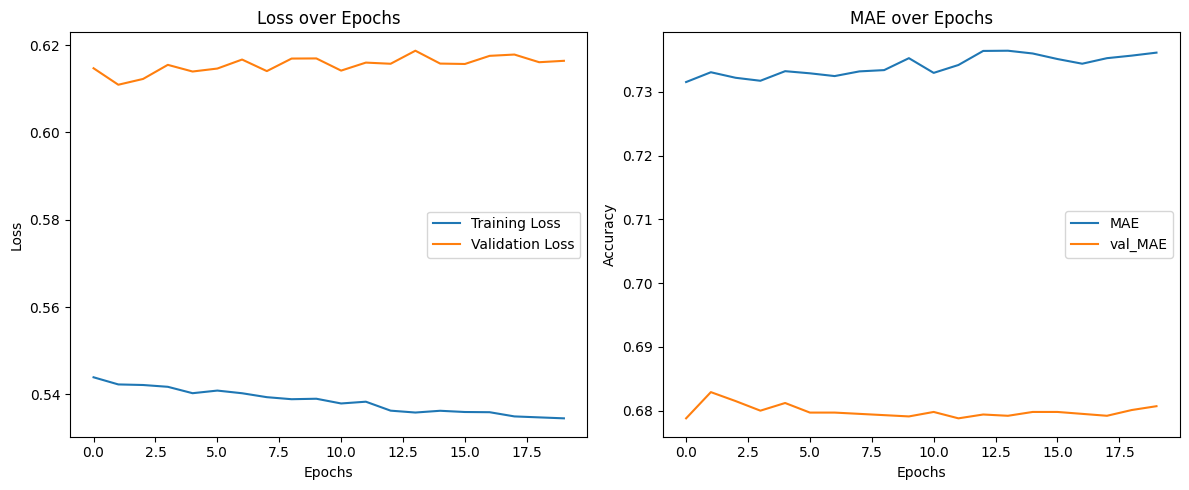

In [119]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))

# Plotting Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plotting Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='MAE')
plt.plot(history.history['val_accuracy'], label='val_MAE')
plt.title('MAE over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [120]:
import jsonpickle

In [121]:
# from sklearn.metrics import r2_score
# predictions = model.predict(X_val)
# r_sq = r2_score(y_val, predictions)
# r_sq

In [122]:
len(model.get_weights())

10

In [123]:
for i in model.get_weights():
    print(i.shape)

(3, 1, 4, 8)
(8,)
(3, 1, 8, 16)
(16,)
(3, 1, 16, 8)
(8,)
(40, 16)
(16,)
(16, 1)
(1,)


In [124]:
weights_tobe_output = model.get_weights() # list of numpy arrays

In [ ]:
model.save('ourmodel.keras')
weights_tobe_output_float32 = [w.astype(np.float32) for w in weights_tobe_output]

In [ ]:
str_output = jsonpickle.encode(weights_tobe_output_float32)
with open('ourweights.json', 'w') as f:
    f.write(str_output)